## CNN(Convolutional Neural Network:-
<pre>
    CNN consists of 4 layer:-
    -> Convolutional Layer
    -> ReLU Layer
    -> Pooling Layer:-
            -> Max Pooling
            -> Avegrage Pooling
    -> Fully Connected Layer
</pre>

In [1]:
import numpy as np
import  matplotlib.pyplot as plt
import keras
from keras.datasets import mnist

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

import random
np.random.seed(0)

In [2]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


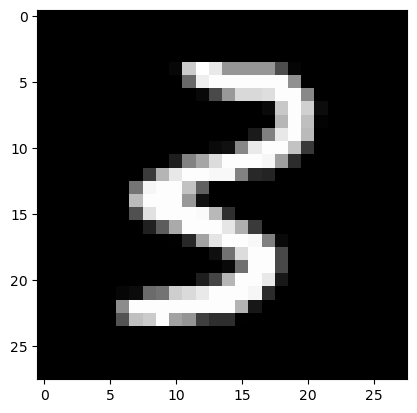

In [4]:
plt.imshow(x_train[y_train == 3][500],cmap = 'gray')
plt.show()

In [5]:
for i in range(0,10):
    print(i, ';', len(x_train[y_train]))

0 ; 60000
1 ; 60000
2 ; 60000
3 ; 60000
4 ; 60000
5 ; 60000
6 ; 60000
7 ; 60000
8 ; 60000
9 ; 60000


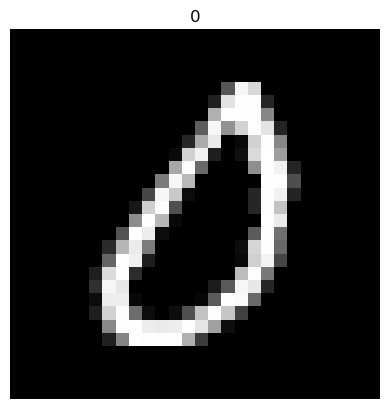

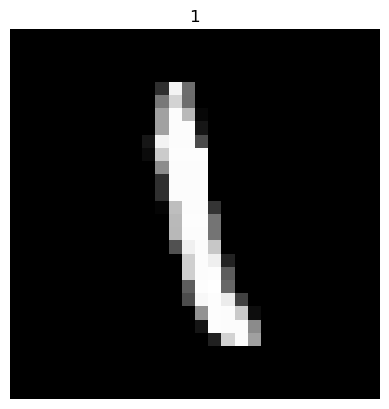

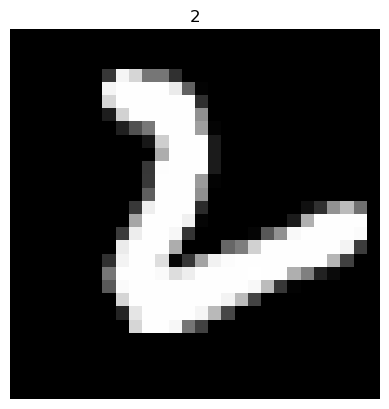

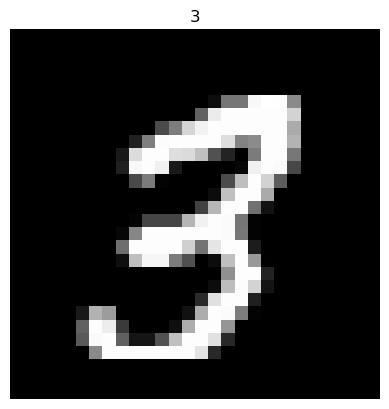

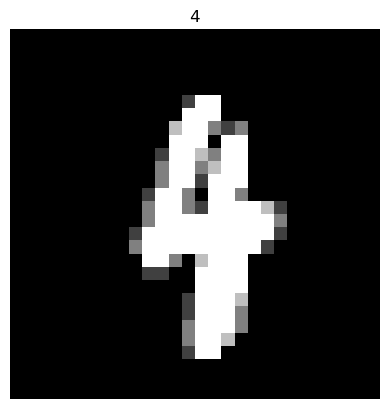

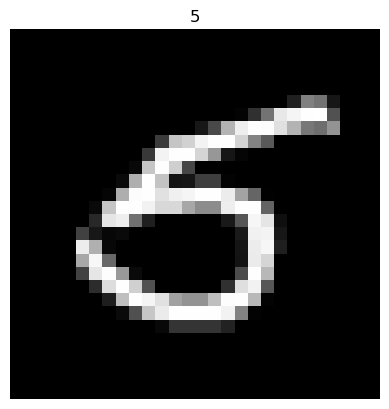

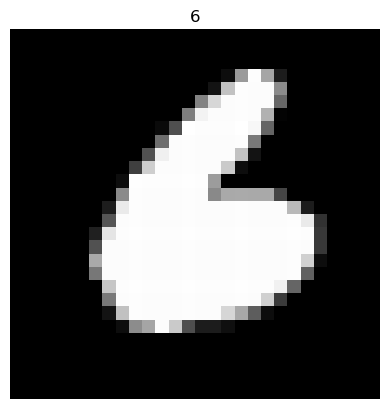

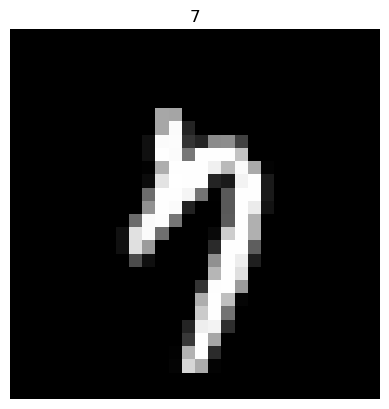

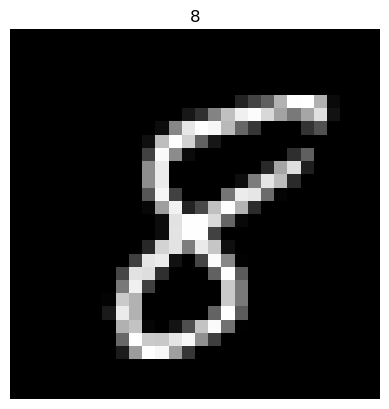

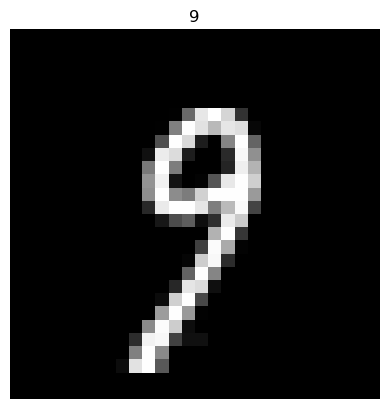

In [6]:
for i in range(0,10):
    plt.imshow(x_train[y_train==i][np.random.randint(0,5400)],cmap = 'gray')
    plt.title(str(i))
    plt.axis('off')
    plt.show()

In [7]:
from keras.utils import to_categorical

In [8]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [9]:
x_train = x_train/255
x_test = x_test/255

In [10]:
x_train.shape

(60000, 28, 28)

In [11]:
x_train=x_train.reshape(60000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)

In [12]:
x_train.shape

(60000, 28, 28, 1)

In [13]:
# CNN model
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten

In [14]:
def Lenet_Model():
    model = Sequential()
    #Convolutional & ReLU Layer
    model.add(Conv2D(30,(5,5),input_shape = (28,28,1),activation = 'relu'))
    #Max pooling Layer
    model.add(MaxPooling2D(pool_size=(2,2)))
    #Convolutional Layer
    model.add(Conv2D(15,(3,3),activation='relu'))
    #Max Pooling Layer
    model.add(MaxPooling2D(pool_size=(2,2)))
    #Flatten Layer
    model.add(Flatten())
    # Hidden Layers
    model.add(Dense(200,activation='relu'))
    model.add(Dense(100,activation='relu'))
    #Output Layer
    model.add(Dense(10,activation='softmax'))
    model.compile(Adam(learning_rate=0.01),loss = 'categorical_crossentropy',metrics = ['accuracy'] )
    return model

In [15]:
model = Lenet_Model()
model.summary()

/Users/nexusop03/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 15)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 375)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │        75,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,155 (395.14 KB)

 Trainable params: 101,155 (395.14 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
h = model.fit(x_train,y_train,validation_split=0.2,epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9325 - loss: 0.2208 - val_accuracy: 0.9616 - val_loss: 0.1463
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9624 - loss: 0.1350 - val_accuracy: 0.9493 - val_loss: 0.1821
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9661 - loss: 0.1247 - val_accuracy: 0.9739 - val_loss: 0.1006
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9682 - loss: 0.1206 - val_accuracy: 0.9692 - val_loss: 0.1215
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9688 - loss: 0.1214 - val_accuracy: 0.9753 - val_loss: 0.0960
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9709 - loss: 0.1134 - val_accuracy: 0.9591 - val_loss: 0.1619
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9715 - loss: 0.1142 - val_accuracy: 0.9732 - val_loss: 0.1295
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9723 - loss: 0.1125 - 

In [17]:
pred = model.predict(x_test)
pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.6705031e-33, 3.4280568e-17, 1.3746629e-19, ..., 1.0000000e+00,
        1.8068321e-16, 5.7978933e-10],
       [1.5620258e-23, 4.5357216e-18, 1.0000000e+00, ..., 1.5737490e-15,
        5.8088325e-24, 3.5389023e-23],
       [4.1763024e-11, 9.9997705e-01, 8.6781271e-13, ..., 6.1869308e-11,
        7.1627959e-08, 4.5760899e-12],
       ...,
       [1.4426557e-16, 3.2562495e-09, 1.2037246e-17, ..., 1.3825045e-08,
        8.1891670e-08, 1.5884989e-03],
       [1.1207035e-11, 7.2469379e-12, 1.5015876e-22, ..., 3.9956954e-15,
        5.7949114e-07, 1.2777605e-07],
       [1.9446067e-07, 1.9708411e-08, 1.3360638e-11, ..., 3.6652659e-36,
        2.3242232e-10, 1.4634444e-10]], dtype=float32)

In [18]:
p = np.argmax(pred,axis = 1)
print(p[0])

7


In [22]:
import cv2

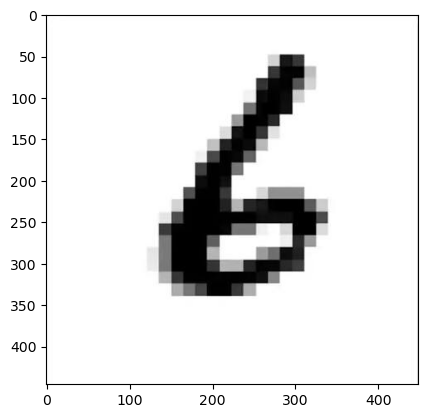

In [27]:
img = cv2.imread('/Users/nexusop03/Downloads/6MNIST.jpeg')
plt.imshow(img,cmap='gray')
plt.show()

In [28]:
from keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [29]:
x_train = x_train/255
x_test = x_test/255

In [30]:
x_train=x_train.reshape(1,28,28,1)
x_test=x_test.reshape(1,28,28,1)

ValueError: cannot reshape array of size 47040000 into shape (1,28,28,1)